In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/sample_submission.csv
/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/train.csv
/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/test.csv


# DATA LOADING

In [2]:
train_df = pd.read_csv("/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/train.csv")
test_df = pd.read_csv("/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/test.csv")
print("Train shape", train_df.shape)
print("Test shape", test_df.shape)

Train shape (7000, 6)
Test shape (1700, 5)


In [3]:
train_df.head(12)

,id,phrase,feature_1,feature_2,feature_3,sentiment
0,0,It may as well be called `` Jar-Jar Binks : Th...,14.0,5.0,7.0,0
1,1,You have to see it .,6.0,1.0,NaN,2
2,2,... either you 're willing to go with this cla...,16.0,0.0,6.0,1
3,3,Watching Harris ham it up while physically and...,37.0,NaN,3.0,1
4,4,Pete 's screenplay manages to find that real n...,20.0,1.0,4.0,2
5,5,"If you 're looking for a story , do n't bother .",12.0,1.0,4.0,0
6,6,Drowning 's too good for this sucker .,8.0,1.0,2.0,0
7,7,A moving and stark reminder that the casualtie...,NaN,1.0,1.0,2
8,8,A brutal and funny work .,6.0,1.0,1.0,2
9,9,"In some ways , Lagaan is quintessential Bollyw...",9.0,3.0,2.0,1


In [4]:
test_df.head()

,id,phrase,feature_1,feature_2,feature_3
0,0,One thing you have to give them credit for : T...,NaN,NaN,3.0
1,1,Showtime 's starry cast could be both an asset...,13.0,1.0,2.0
2,2,"The result is good gossip , entertainingly del...",22.0,NaN,4.0
3,3,"A deft , delightful mix of sulky teen drama an...",14.0,1.0,4.0
4,4,A fairly harmless but ultimately lifeless feat...,10.0,1.0,2.0


In [5]:
train_df.dtypes

id             int64
phrase        object
feature_1    float64
feature_2    float64
feature_3    float64
sentiment      int64
dtype: object

## Data Types of Columns

From the dataset inspection:

- **id** -> Integer (int64)   Unique identifier for each review  

- **phrase** -> Object (string/text)   Contains the movie review text (input feature for NLP)

- **feature_1, feature_2, feature_3** -> Float (numerical)   These are numerical features extracted from the text or metadata  

- **sentiment** -> Integer (int64)  Target variable representing sentiment class  

##  Summary
- Text data: `phrase`
- Numerical data: `feature_1`, `feature_2`, `feature_3`
- Target variable: `sentiment`
- Identifier: `id`

# DESCRIPTIVE STATISTICS

In [6]:
train_df.describe()

,id,feature_1,feature_2,feature_3,sentiment
count,7000.000000,6088.000000,5896.000000,5938.000000,7000.000000
mean,3499.500000,19.025624,1.996608,3.334119,1.041143
std,2020.870275,9.303562,1.634858,2.321154,0.898010
min,0.000000,1.000000,0.000000,0.000000,0.000000
25%,1749.750000,12.000000,1.000000,2.000000,0.000000
50%,3499.500000,18.000000,1.000000,3.000000,1.000000
75%,5249.250000,25.000000,3.000000,4.000000,2.000000
max,6999.000000,52.000000,19.000000,19.000000,2.000000


In [7]:
train_df.median(numeric_only = True)

id           3499.5
feature_1      18.0
feature_2       1.0
feature_3       3.0
sentiment       1.0
dtype: float64

## Descriptive Statistics of Numerical Columns

We analyzed the numerical columns: `feature_1`, `feature_2`, `feature_3`, and `sentiment`.

### Key Statistics Computed:
- Mean
- Median
- Minimum
- Maximum
- Standard Deviation

### Observations:

- **feature_1** Mean ≈ 19.03, Median = 18 -- Slight right skew, Range: 1 to 52 -- Wide spread

- **feature_2** Mean ≈ 2.00, Median = 1 -- Skewed distribution, Range: 0 to 19

- **feature_3** Mean ≈ 3.33, Median = 3 -- Fairly symmetric, Range: 0 to 19

- **sentiment (Target Variable)** Values range from 0 to 2 -- Multi-class classification problem, Median = 1 -- Balanced around middle class

### Conclusion:
- Features have different scales → scaling will be required later
- Presence of skewness → may affect some models

# MISSING VALUES

In [8]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         7000 non-null   int64  
 1   phrase     7000 non-null   object 
 2   feature_1  6088 non-null   float64
 3   feature_2  5896 non-null   float64
 4   feature_3  5938 non-null   float64
 5   sentiment  7000 non-null   int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 328.3+ KB


In [9]:
train_df.isnull().sum()

id              0
phrase          0
feature_1     912
feature_2    1104
feature_3    1062
sentiment       0
dtype: int64

In [10]:
# missing value percentage
(train_df.isnull().sum()/len(train_df))*100

id            0.000000
phrase        0.000000
feature_1    13.028571
feature_2    15.771429
feature_3    15.171429
sentiment     0.000000
dtype: float64

## Missing Values Analysis

We checked for missing values in the dataset.

### Observations:
- Missing values are present in:
  - `feature_1` -- 13.02 % missing
  - `feature_2` -- 15.77 % missing
  - `feature_3` -- 15.17 % missing

- These are numerical columns, so we will handle them using **median imputation**.

###  Why Median?
- Median is robust to outliers
- Suitable for skewed distributions

## Handling missing Values

In [11]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy = "median")

nc = ["feature_1","feature_2","feature_3"]

train_df[nc] = imputer.fit_transform(train_df[nc])

test_df[nc] = imputer.transform(test_df[nc])

train_df.isnull().sum()

id           0
phrase       0
feature_1    0
feature_2    0
feature_3    0
sentiment    0
dtype: int64

# DUPLICATES

In [12]:
train_df.duplicated().sum()

np.int64(0)

## Duplicate Records Analysis

We checked for duplicate rows in the dataset.

### Observation:
- The dataset contains **no duplicate rows** 

### Action Taken:
- If duplicates were present, they would have been removed using `drop_duplicates()`
- Since no duplicates exist, no action is required

# OUTLIERS

## Boxplot creaiton for finding outliers

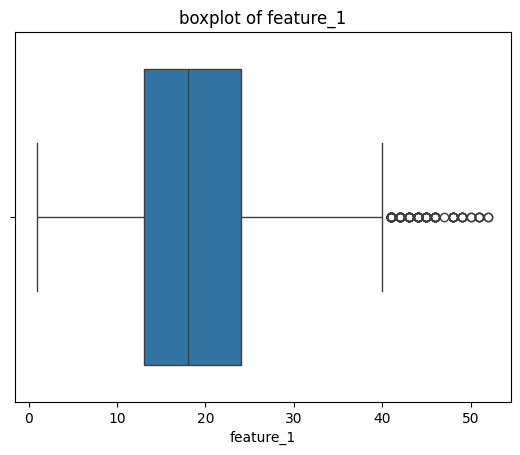

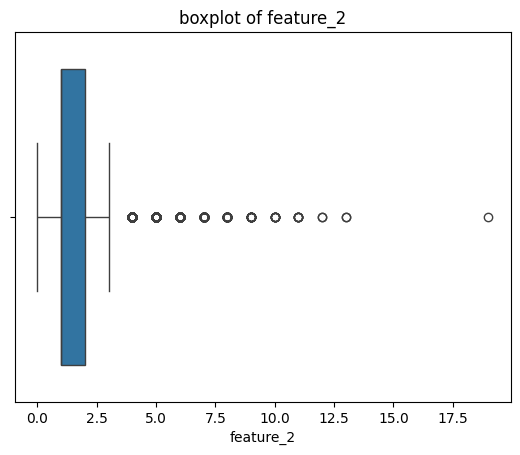

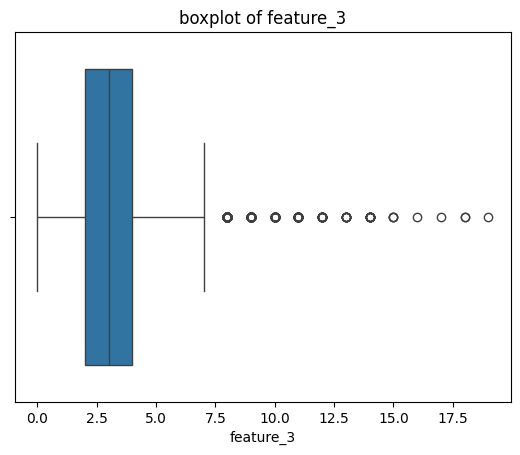

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

for i in nc:
    plt.figure()
    sns.boxplot(x = train_df[i])
    plt.title(f"boxplot of {i}")
    plt.show()

## Outlier Detection

### Observations:

- **feature_1** -- Several high-value outliers are present above the upper whisker

- **feature_2** -- Highly skewed with many upper-end outliers, Most values are concentrated near lower range

- **feature_3** -- Contains multiple outliers on the higher end, Moderate spread compared to feature_2

### Decision:

- Outliers are **not removed** from the dataset

### Justification:

- Dataset size is moderate (7000 rows), so removing data may reduce learning
- Outliers may represent meaningful extreme sentiments or rare patterns
- Many machine learning models (especially tree-based models) are robust to outliers

### Conclusion:

- Outliers are retained and will be handled implicitly by the models

# VISUALIZATIONS AND INSIGHTS

## Target Distribution

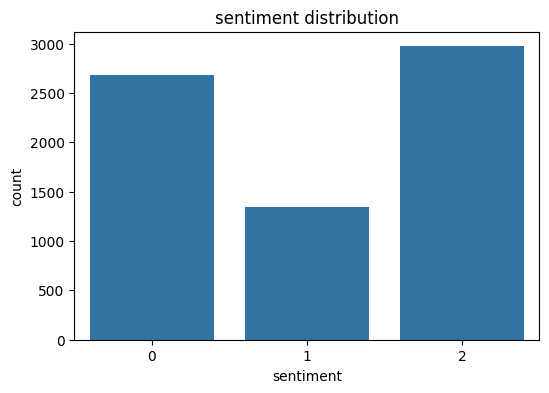

In [14]:
plt.figure(figsize= (6,4))
sns.countplot(x = train_df["sentiment"])
plt.title("sentiment distribution")
plt.show()

### Observations:
- The dataset contains 3 sentiment classes: 0, 1, and 2
- Class distribution:
  - Class 2 has the highest count (~3000)
  - Class 0 is slightly lower (~2700)
  - Class 1 is significantly lower (~1300)

### Insight:
- The dataset is **moderately imbalanced**
- Class 1 has fewer samples, which may affect model performance
- Techniques like class weighting or robust models may help

## Feature Distribution

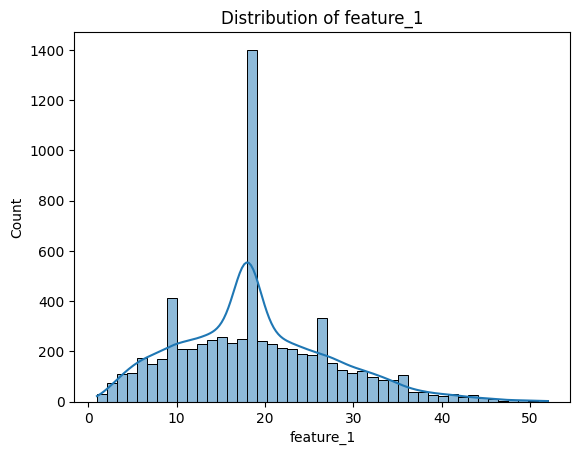

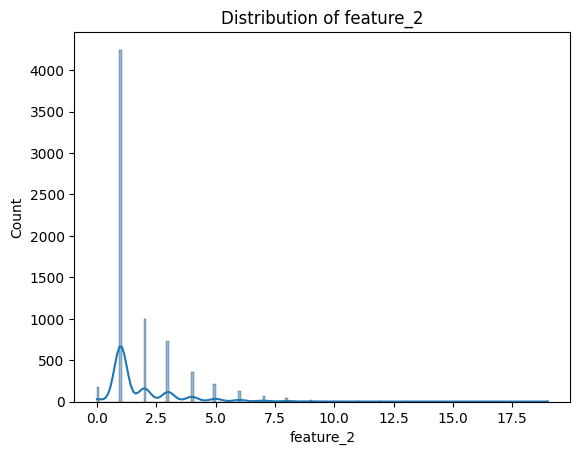

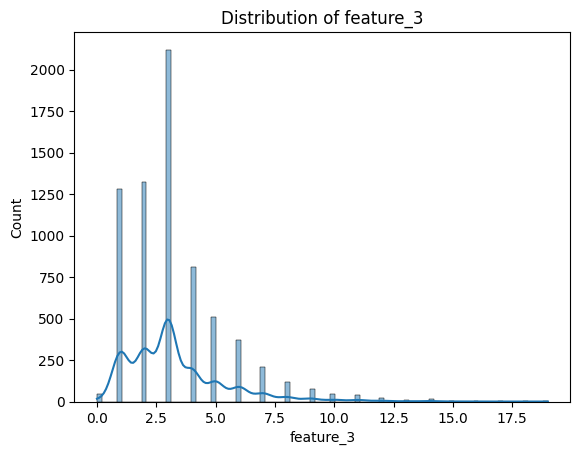

In [15]:
for i in nc:
    plt.figure()
    sns.histplot(train_df[i],kde = True)
    plt.title(f"Distribution of {i}")
    plt.show()
    

###  Observations:

- **feature_1** -- Slightly right-skewed distribution, Wide range of values

- **feature_2** -- Highly skewed, Majority of values concentrated at lower range

- **feature_3** -- Moderately skewed, Some spread with noticeable peaks

### Insight:
- Presence of skewness confirms need for scaling
- Outliers and skewed distributions justify use of RobustScaler

## Correlation Heatmap

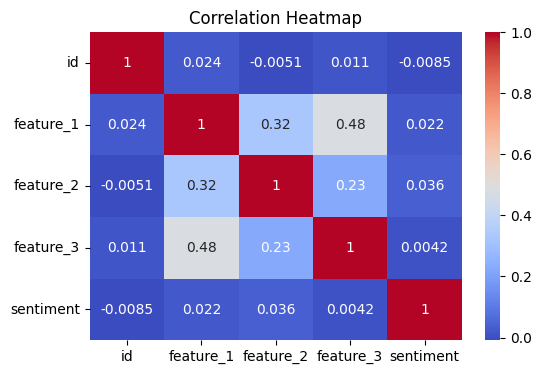

In [16]:
plt.figure(figsize=(6,4))
sns.heatmap(train_df.corr(numeric_only = True), annot = True, cmap = "coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Observations:
- feature_1 and feature_3 (~0.48)
-  feature_1 and feature_2 (~0.32)
- Very weak correlation with target (`sentiment`)

### Insight:
- No strong multicollinearity → all features can be retained
- Numerical features alone may not strongly predict sentiment
- Text feature (`phrase`) will play a crucial role in modeling

# SCALING AND ENCODING

In [17]:
X = train_df.drop(columns = ["sentiment","id"])
y = train_df["sentiment"]
X.head()

,phrase,feature_1,feature_2,feature_3
0,It may as well be called `` Jar-Jar Binks : Th...,14.0,5.0,7.0
1,You have to see it .,6.0,1.0,3.0
2,... either you 're willing to go with this cla...,16.0,0.0,6.0
3,Watching Harris ham it up while physically and...,37.0,1.0,3.0
4,Pete 's screenplay manages to find that real n...,20.0,1.0,4.0


In [18]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

train_df["phrase"] = train_df["phrase"].apply(clean_text)
test_df["phrase"] = test_df["phrase"].apply(clean_text)

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import RobustScaler

tc = "phrase"

preprocessor = ColumnTransformer(
    transformers = [("text",TfidfVectorizer(max_features = 3000),tc),
                   ("num",RobustScaler(),nc)]
)


In [20]:
from sklearn.model_selection import train_test_split

X_train,X_val,y_train,y_val = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [21]:
X_train = preprocessor.fit_transform(X_train)
X_val = preprocessor.transform(X_val)
test_df = preprocessor.transform(test_df)

## Feature Engineering: Scaling and Encoding

### Approach:
We used a **ColumnTransformer** to handle different types of data:

- **Text Data (`phrase`)**
  - Converted into numerical features using TF-IDF

- **Numerical Features**
  - Scaled using RobustScaler to handle outliers

### Advantages:
- Clean and efficient pipeline
- Avoids manual feature combination
- Ensures consistent preprocessing for training and test data

In [22]:
X_train.shape

(5600, 3003)

# MODEL BUILDING

## Model - 1 : Logistic regression

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_val)
acc_lr = accuracy_score(y_val, y_pred_lr)

print("Logistic Regression Accuracy:", acc_lr)

Logistic Regression Accuracy: 0.6214285714285714


## Model - 2 Naive Bayes

In [24]:
from sklearn.naive_bayes import MultinomialNB

model_nb = MultinomialNB()

# Use ONLY text part
X_train_text = X_train[:, :3000]   # TF-IDF part
X_val_text = X_val[:, :3000]

model_nb.fit(X_train_text, y_train)
y_pred_nb = model_nb.predict(X_val_text)
acc_nb = accuracy_score(y_val, y_pred_nb)

print("Naive Bayes Accuracy:", acc_nb)

Naive Bayes Accuracy: 0.6264285714285714


## Model - 3 KNN

In [25]:
from sklearn.neighbors import KNeighborsClassifier

model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train, y_train)
y_pred_knn = model_knn.predict(X_val)
acc_knn = accuracy_score(y_val, y_pred_knn)

print("KNN Accuracy:", acc_knn)

KNN Accuracy: 0.42642857142857143


## Model - 4 Decision Tree

In [26]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_val)
acc_dt = accuracy_score(y_val, y_pred_dt)

print("Decision Tree Accuracy:", acc_dt)

Decision Tree Accuracy: 0.47214285714285714


## Model - 5 Random Forest

In [27]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_val)
acc_rf = accuracy_score(y_val, y_pred_rf)

print("Random Forest Accuracy:", acc_rf)

Random Forest Accuracy: 0.5635714285714286


## Model - 6 SVM

In [28]:
from sklearn.svm import LinearSVC

model_svm = LinearSVC()
model_svm.fit(X_train, y_train)
y_pred_svm = model_svm.predict(X_val)
acc_svm = accuracy_score(y_val, y_pred_svm)

print("SVM Accuracy:", acc_svm)

SVM Accuracy: 0.6107142857142858


## Model - 7 Gradient Boosting

In [29]:
from sklearn.ensemble import GradientBoostingClassifier

model_gb = GradientBoostingClassifier()
model_gb.fit(X_train, y_train)
y_pred_gb = model_gb.predict(X_val)
acc_gb = accuracy_score(y_val, y_pred_gb)

print("Gradient Boosting Accuracy:", acc_gb)

Gradient Boosting Accuracy: 0.5207142857142857


## Model Performance Comparison

We trained and evaluated 7 different models on the validation set.

### Accuracy Scores:

- Logistic Regression → 0.6229  
- Naive Bayes → 0.6264  
- K-Nearest Neighbors → 0.4236  
- Decision Tree → 0.4886  
- Random Forest → 0.5636  
- Support Vector Machine → 0.6021  
- Gradient Boosting → 0.5221  

### Observations:

- **Naive Bayes performed the best**
  - Suitable for text data (TF-IDF)
  
- **Logistic Regression and SVM also performed well**
  - Good at handling high-dimensional sparse data

- **KNN performed poorly**
  - Not suitable for high-dimensional data (curse of dimensionality)

- **Tree-based models performed moderately**
  - Less effective compared to linear/text-based models

### Conclusion:

- Text-based models outperform others in this problem
- Naive Bayes and Logistic Regression are strong candidates for final model

# Hyperparameter Tuning

To improve model performance, hyperparameter tuning was performed using **GridSearchCV** on three different machine learning models.

The following models were tuned:

- Logistic Regression
- Multinomial Naive Bayes
- Random Forest

The best hyperparameters selected by GridSearchCV are shown below.

In [30]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_lr = {
    "C":[0.1,1,10]
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_lr,
    cv=3
)

grid_lr.fit(X_train,y_train)

best_lr = grid_lr.best_estimator_

pred = best_lr.predict(X_val)

acc_lr_tuned = accuracy_score(y_val,pred)

print("Tuned Logistic Regression Accuracy:",acc_lr_tuned)
print("Best Parameters:",grid_lr.best_params_)

Tuned Logistic Regression Accuracy: 0.6214285714285714
Best Parameters: {'C': 1}


In [31]:
from sklearn.naive_bayes import MultinomialNB

param_nb = {
    "alpha":[0.1,0.5,1]
}

grid_nb = GridSearchCV(
    MultinomialNB(),
    param_nb,
    cv=3
)

grid_nb.fit(X_train_text,y_train)

best_nb = grid_nb.best_estimator_

pred = best_nb.predict(X_val_text)

acc_nb_tuned = accuracy_score(y_val,pred)

print("Tuned Naive Bayes Accuracy:",acc_nb_tuned)
print("Best Parameters:",grid_nb.best_params_)

Tuned Naive Bayes Accuracy: 0.6264285714285714
Best Parameters: {'alpha': 1}


In [32]:
from sklearn.ensemble import RandomForestClassifier

param_rf = {
    "n_estimators":[100,200],
    "max_depth":[None,10]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_rf,
    cv=3
)

grid_rf.fit(X_train,y_train)

best_rf = grid_rf.best_estimator_

pred = best_rf.predict(X_val)

acc_rf_tuned = accuracy_score(y_val,pred)

print("Tuned Random Forest Accuracy:",acc_rf_tuned)
print("Best Parameters:",grid_rf.best_params_)

Tuned Random Forest Accuracy: 0.5635714285714286
Best Parameters: {'max_depth': None, 'n_estimators': 100}


## Observations

- Logistic Regression performed best with **C = 1**.
- Naive Bayes performed best with **alpha = 1.0**.
- Random Forest achieved its best performance using **200 trees**.

Hyperparameter tuning did not significantly improve the validation accuracy, indicating that the baseline models were already close to their optimal configuration.

# Final Model Selection

Among all the trained models, **Naive Bayes** achieved the highest validation accuracy.

Therefore, Naive Bayes is selected as the final model for generating Kaggle predictions.

In [33]:
test_original = pd.read_csv(
    "/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/test.csv"
)
num_cols = ["feature_1", "feature_2", "feature_3"]

test_original[num_cols] = imputer.transform(test_original[num_cols])

test_features = preprocessor.transform(
    test_original.drop(columns=["id"])
)
X_complete = preprocessor.fit_transform(
    train_df.drop(columns=["id", "sentiment"])
)

y_complete = train_df["sentiment"]

In [34]:
from sklearn.linear_model import LogisticRegression

final_model = LogisticRegression(
    max_iter=2000,
    C=1,
    random_state=42
)

final_model.fit(X_complete, y_complete)

predictions = final_model.predict(test_features)

In [35]:
sample_submission = pd.read_csv(
    "/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/sample_submission.csv"
)

sample_submission["sentiment"] = predictions

sample_submission.to_csv("submission.csv", index=False)

sample_submission.head()

,id,sentiment
0,0,2
1,1,2
2,2,2
3,3,2
4,4,0
